#Previsão de risco de burnout acadêmico em contextos de ferramentas de IA

##1. Identificação e descrição do problema

Título:
*   Previsão de risco de burnout acadêmico em contextos de ferramentas de IA

Grupo:
*   Julyana Azevedo Lima ([github](https://github.com/julyana-ai))
*   Murilo Santos de Santana ([github](https://github.com/MuriloSantanaUFS))

Fonte escolhida:
*  Dataset escolhido: Impact of AI on Students ([Kaggle](https://www.kaggle.com/datasets/laveshjadon/ai-impact-on-students))

Objetivo:
* O objetivo principal deste projeto é desenvolver e comparar modelos de classificação supervisionada para prever o nível de risco de burnout (Baixo, Médio ou Alto) de estudantes universitários, utilizando como preditores padrões de uso de ferramentas de IA generativa, hábitos de estudo tradicionais (carga horária), indicadores de desempenho acadêmico (GPA), fatores psicossociais (ansiedade, dependência percebida) e contexto institucional (curso e políticas acadêmicas).

Atributo-alvo:
* Nível de Risco de burnout (`Burnout_Risk_Level`)

Atributos preditivos
* Comportamentais (uso de IA): `Weekly_GenAI_Hours`, `Primary_Use_Case`, `Tool_Diversity`, `Paid_Subscription`, `Prompt_Engineering_Skill`
* Comportamentais (estudo): `Traditional_Study_Hours`, `Major_Category`, `Year_of_Study`
* Desempenho acadêmico: `Pre_Semester_GPA`, `Post_Semester_GPA`, `Skill_Retention_Score`
* Institucional: `Institutional_Policy`
* Percepção/estado do estudante: `Anxiety_Level_During_Exams`, `Perceived_AI_Dependency`

Tipo da tarefa
* Escolhemos por classificação (multiclasse (3 classes)), já que o atributo-alvo representa categorias ordenadas de risco, e não um valor numérico contínuo. Nosso atributo-alvo é dividido em 3 classes: baixo, médio e alto.

##2. Configuração do Notebook e Compreensão dos dados
Para que os dados carreguem com a indepedência de arquivo local, iremos importar diretamente da biblioteca pública `kagglehub`. Também iremos usar as bibliotecas já pertencentes a execução do Google colab: pandas, numpy, matplotlib, seaborn.


In [39]:
import kagglehub
import pandas as pd
import os

caminho = kagglehub.dataset_download("laveshjadon/ai-impact-on-students")

nome_arquivo = "ai_student_impact_dataset (1).csv"
df = pd.read_csv(os.path.join(caminho, nome_arquivo))


df.head()

Using Colab cache for faster access to the 'ai-impact-on-students' dataset.


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [40]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


#Compreensão dos dados:
##2.1 Dimensão do dataset escolhido
O conjunto de dados possui 50.000 registros e 16 atributos, sendo um deles (`Student_ID`) um identificador sem valor preditivo, e outro (`Burnout_Risk_Level`), o *atributo-alvo*.

Restam, portanto, 14 atributos candidatos a preditores. O volume de registros é amplo o suficiente para permitir separação robusta entre treino e teste, além de validação cruzada durante a comparação de modelos, sem risco de escassez de dados.

In [41]:
##2.1 Dimensão do dataset escolhido
print(f"Número de registros: {df.shape[0]:,}".replace(",", "."))
print(f"Número de atributos: {df.shape[1]}")

Número de registros: 50.000
Número de atributos: 16


##2.2 Tipo de variáveis
O dataset combina três tipos de variáveis: *numéricas contínuas* (`Pre_Semester_GPA`, `Weekly_GenAI_Hours`, `Traditional_Study_Hours`, `Post_Semester_GPA`, `Skill_Retention_Score`), *numéricas discretas/ordinais* (`Tool_Diversity`, `Perceived_AI_Dependency`, `Anxiety_Level_During_Exams`, escalas de 1 a 10), *categóricas nominais* (`Major_Category`, `Primary_Use_Case`, `Institutional_Policy`), *categóricas ordinais* (`Year_of_Study`, `Prompt_Engineering_Skill`) e *uma variável booleana* (`Paid_Subscription`). Essa mistura de tipos exigirá estratégias de pré-processamento distintas — codificação para as categóricas e, possivelmente, escalonamento para as numéricas, dependendo do modelo.

In [42]:
#2.2 Tipo de variáveis:
df.dtypes

,0
Student_ID,int64
Major_Category,object
Year_of_Study,object
Pre_Semester_GPA,float64
Weekly_GenAI_Hours,float64
Primary_Use_Case,object
Prompt_Engineering_Skill,object
Tool_Diversity,int64
Paid_Subscription,bool
Traditional_Study_Hours,float64


##2.3 Valores ausentes
Não há nenhum valor ausente em nenhuma das 16 colunas. Embora isso simplifique o pré-processamento (*não será necessária imputação*), é importante registrar que essa ausência total de valores nulos, somada à ausência completa de duplicatas (verificado a seguir), é estatisticamente incomum para dados de comportamento humano coletados na prática, sendo um indício de que o conjunto de dados foi gerado sinteticamente para fins didáticos.


In [43]:
##2.3 Valores ausentes
df.isnull().sum()

,0
Student_ID,0
Major_Category,0
Year_of_Study,0
Pre_Semester_GPA,0
Weekly_GenAI_Hours,0
Primary_Use_Case,0
Prompt_Engineering_Skill,0
Tool_Diversity,0
Paid_Subscription,0
Traditional_Study_Hours,0


##2.4 Duplicações
Não foram encontradas linhas duplicadas no conjunto de dados. *Isso reforça a hipótese de dataset sintético*, mas também elimina a necessidade de uma etapa de deduplicação no pré-processamento.

In [44]:
##2.4 Duplicações
print(f"Linhas duplicadas: {df.duplicated().sum()}")

Linhas duplicadas: 0


##2.5 Estatísticas descritivas das variáveis numéricas
As estatísticas descritivas mostram, por exemplo, que `Weekly_GenAI_Hours` varia de valores próximos de zero até um máximo de 40 horas semanais, com boa dispersão — o que sugere variabilidade real de comportamento entre estudantes, sem sinais evidentes de valores implausíveis (como negativos ou fora de uma faixa razoável).

O `Pre_Semester_GPA` e `Post_Semester_GPA` estão numa escala de 0 a 4 (compatível com o sistema de GPA -notas- norte-americano), e o `Skill_Retention_Score` varia numa escala de 0 a 100.

Não há, à primeira vista, valores fora do domínio esperado para cada variável — o que será revisitado com mais rigor na análise exploratória (seção 3), por meio de boxplots, para identificar possíveis outliers.

In [45]:
##2.5 Estatísticas descritivas das variáveis numéricas
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


##2.6 Variáveis categóricas: contagem de categorias
As variáveis categóricas apresentam poucas categorias cada (*entre 2 e 5*), sem valores inconsistentes aparentes (*como grafias diferentes para a mesma categoria, espaços extras ou erros de digitação*). Isso indica que a codificação categórica poderá ser aplicada diretamente, sem necessidade de normalização textual prévia.

Nas próximas células, trazemos a compreensão do atributo-alvo escolhido:

In [46]:
##2.6 Variáveis categóricas: contagem de categorias

colunas_categoricas = ['Major_Category', 'Year_of_Study', 'Primary_Use_Case',
                        'Prompt_Engineering_Skill', 'Institutional_Policy']

for col in colunas_categoricas:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Major_Category ---
Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

--- Year_of_Study ---
Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430
Name: count, dtype: int64

--- Primary_Use_Case ---
Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340
Name: count, dtype: int64

--- Prompt_Engineering_Skill ---
Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64

--- Institutional_Policy ---
Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788
Name: count, dtype: int64


##2.7 Distribuição do atributo-alvo
O atributo-alvo Burnout_Risk_Level apresenta a seguinte distribuição: Medium (42,3%), Low (32,7%) e High (25,0%). Trata-se de um desbalanceamento leve a moderado — não há uma classe dominante extrema (como 90% vs. 10%), mas a classe High é visivelmente minoritária em relação às demais. Esse desbalanceamento tem **duas implicações práticas** para as próximas etapas do trabalho:

(1) a separação entre treino e teste deverá ser estratificada, garantindo que a proporção das três classes seja preservada em ambos os conjuntos;

e (2) a avaliação dos modelos (seção 7) não deverá se basear apenas na acurácia — visto que um classificador ingênuo que sempre previsse "Medium" já acertaria 42,3% dos casos sem aprender nenhum padrão real —, sendo necessário priorizar métricas como F1-score macro, que pondera igualmente o desempenho nas três classes.

A próxima célula representa o gráfico de barras e esse gráfico confirma visualmente o padrão observado nas contagens: a *classe Medium é a mais frequente*, seguida por Low e, por último, High. A diferença entre as classes não é drástica o suficiente para justificar técnicas agressivas de balanceamento (como oversampling ou undersampling), mas será levada em conta na escolha das métricas de avaliação.

In [47]:
##2.7 Distribuição do atributo-alvo
print(df['Burnout_Risk_Level'].value_counts())
print()
print(df['Burnout_Risk_Level'].value_counts(normalize=True).round(4) * 100)

Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64

Burnout_Risk_Level
Medium    42.29
Low       32.74
High      24.97
Name: proportion, dtype: float64


##2.8 Visualização da distribuição do alvo
O gráfico de barras confirma visualmente o padrão observado nas contagens: a classe Medium é a mais frequente, seguida por Low e, por último, High. A diferença entre as classes não é drástica o suficiente para justificar técnicas agressivas de balanceamento (como oversampling ou undersampling), mas será levada em conta na escolha das métricas de avaliação.

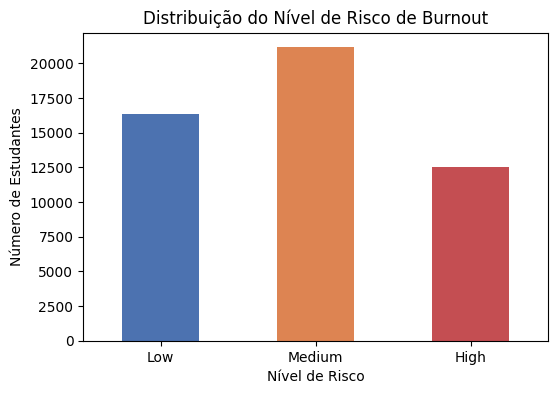

In [48]:
##2.8 Visualização da distribuição do alvo
import matplotlib.pyplot as plt
#nosso atributo alvo
contagem = df['Burnout_Risk_Level'].value_counts().reindex(['Low', 'Medium', 'High'])

plt.figure(figsize=(6,4))
contagem.plot(kind='bar', color=['#4C72B0', '#DD8452', '#C44E52'])
plt.title('Distribuição do Nível de Risco de Burnout')
plt.xlabel('Nível de Risco')
plt.ylabel('Número de Estudantes')
plt.xticks(rotation=0)
plt.show()

##2.9 Confirmação dos tipos de variável e verificação de valores nulos

Além das estatísticas descritivas apresentadas, usamos o `df.info()` para confirmar os tipos de dado de cada variável e verificar a ausência de valores nulos em todas as colunas. Também verificamos a quantidade de valores únicos por coluna (`df.nunique()`) para confirmar a natureza categórica/ordinal de algumas variáveis e validar as três classes do nosso atributo-alvo.

Com isso, concluímos a seção 2.

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [50]:
df.nunique()

,0
Student_ID,50000
Major_Category,5
Year_of_Study,5
Pre_Semester_GPA,2389
Weekly_GenAI_Hours,3566
Primary_Use_Case,5
Prompt_Engineering_Skill,3
Tool_Diversity,5
Paid_Subscription,2
Traditional_Study_Hours,2516



#3. Análise Exploratória dos Dados

Nesta etapa será realizada uma análise exploratória do conjunto de dados com o objetivo de identificar padrões, distribuições e possíveis relações entre os atributos preditores e o atributo-alvo `Burnout_Risk_Level`.

**Observação:** Nesta seção, a análise exploratória foi realizada utilizando todo o conjunto de dados (`df`), com o objetivo de compreender suas características gerais. A divisão entre os conjuntos de treino e teste será realizada posteriormente, durante a etapa de preparação dos dados para a modelagem.

In [51]:
df['Burnout_Risk_Level'].value_counts()

,count
Burnout_Risk_Level,
Medium,21144
Low,16369
High,12487


##3.1 Horas semanais de uso de IA

O boxplot permite comparar a distribuição das horas semanais de uso de IA entre os diferentes níveis de burnout. A análise busca identificar se estudantes classificados com maior risco apresentam um padrão diferente de utilização da inteligência artificial em comparação aos demais grupos.

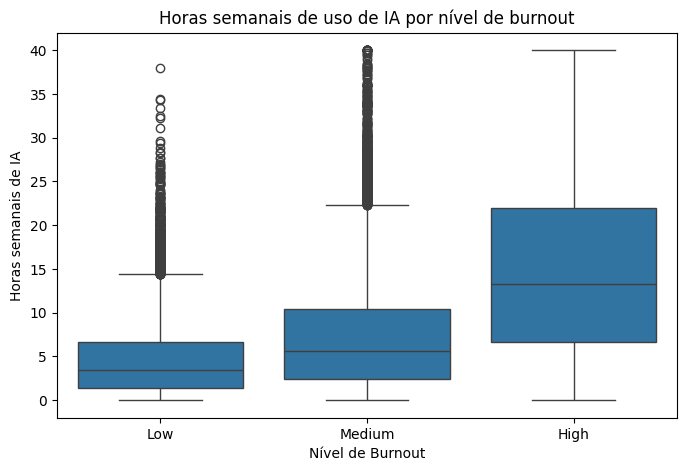

In [52]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Burnout_Risk_Level",
    y="Weekly_GenAI_Hours",
    order=["Low", "Medium", "High"]
)

plt.title("Horas semanais de uso de IA por nível de burnout")
plt.xlabel("Nível de Burnout")
plt.ylabel("Horas semanais de IA")

plt.show()

##3.2 Dependência percebida de IA
A variável Perceived_AI_Dependency representa o nível de dependência percebida pelos estudantes em relação às ferramentas de inteligência artificial. A comparação entre as classes permite verificar se maiores níveis de dependência estão associados a maiores riscos de burnout. Essa análise ajuda a identificar possíveis padrões comportamentais relacionados ao uso da IA.

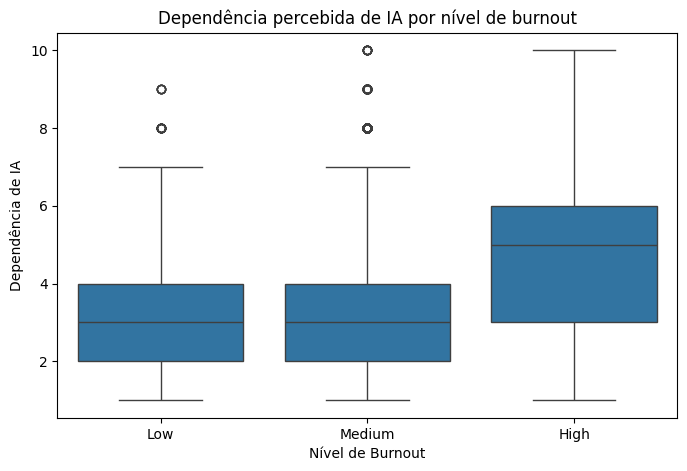

In [53]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Burnout_Risk_Level",
    y="Perceived_AI_Dependency",
    order=["Low", "Medium", "High"]
)

plt.title("Dependência percebida de IA por nível de burnout")
plt.xlabel("Nível de Burnout")
plt.ylabel("Dependência de IA")

plt.show()

##3.3 Ansiedade durante provas
A variável Anxiety_Level_During_Exams é analisada para verificar sua relação com os níveis de burnout. A comparação entre as classes permite observar se estudantes com maior risco apresentam níveis mais elevados de ansiedade durante avaliações, indicando que fatores emocionais podem estar associados ao esgotamento acadêmico.

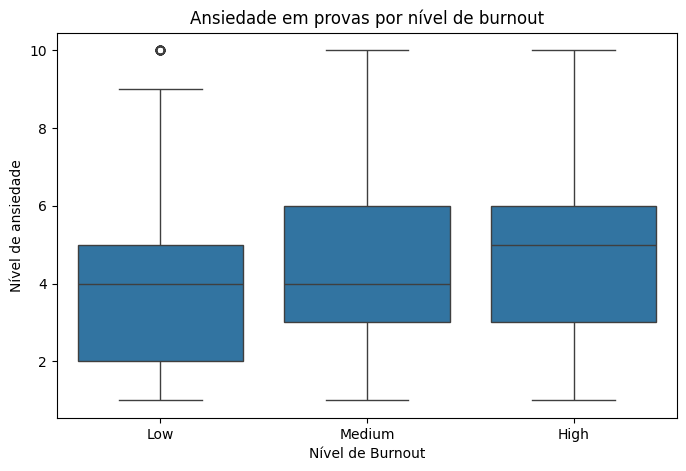

In [54]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Burnout_Risk_Level",
    y="Anxiety_Level_During_Exams",
    order=["Low", "Medium", "High"]
)

plt.title("Ansiedade em provas por nível de burnout")
plt.xlabel("Nível de Burnout")
plt.ylabel("Nível de ansiedade")

plt.show()

##3.4 Distribuição das variáveis numéricas
Os histogramas apresentam a distribuição das variáveis numéricas do conjunto de dados. Essa análise permite observar a concentração dos valores, possíveis assimetrias e identificar se existem comportamentos extremos que devem ser considerados durante o pré-processamento.

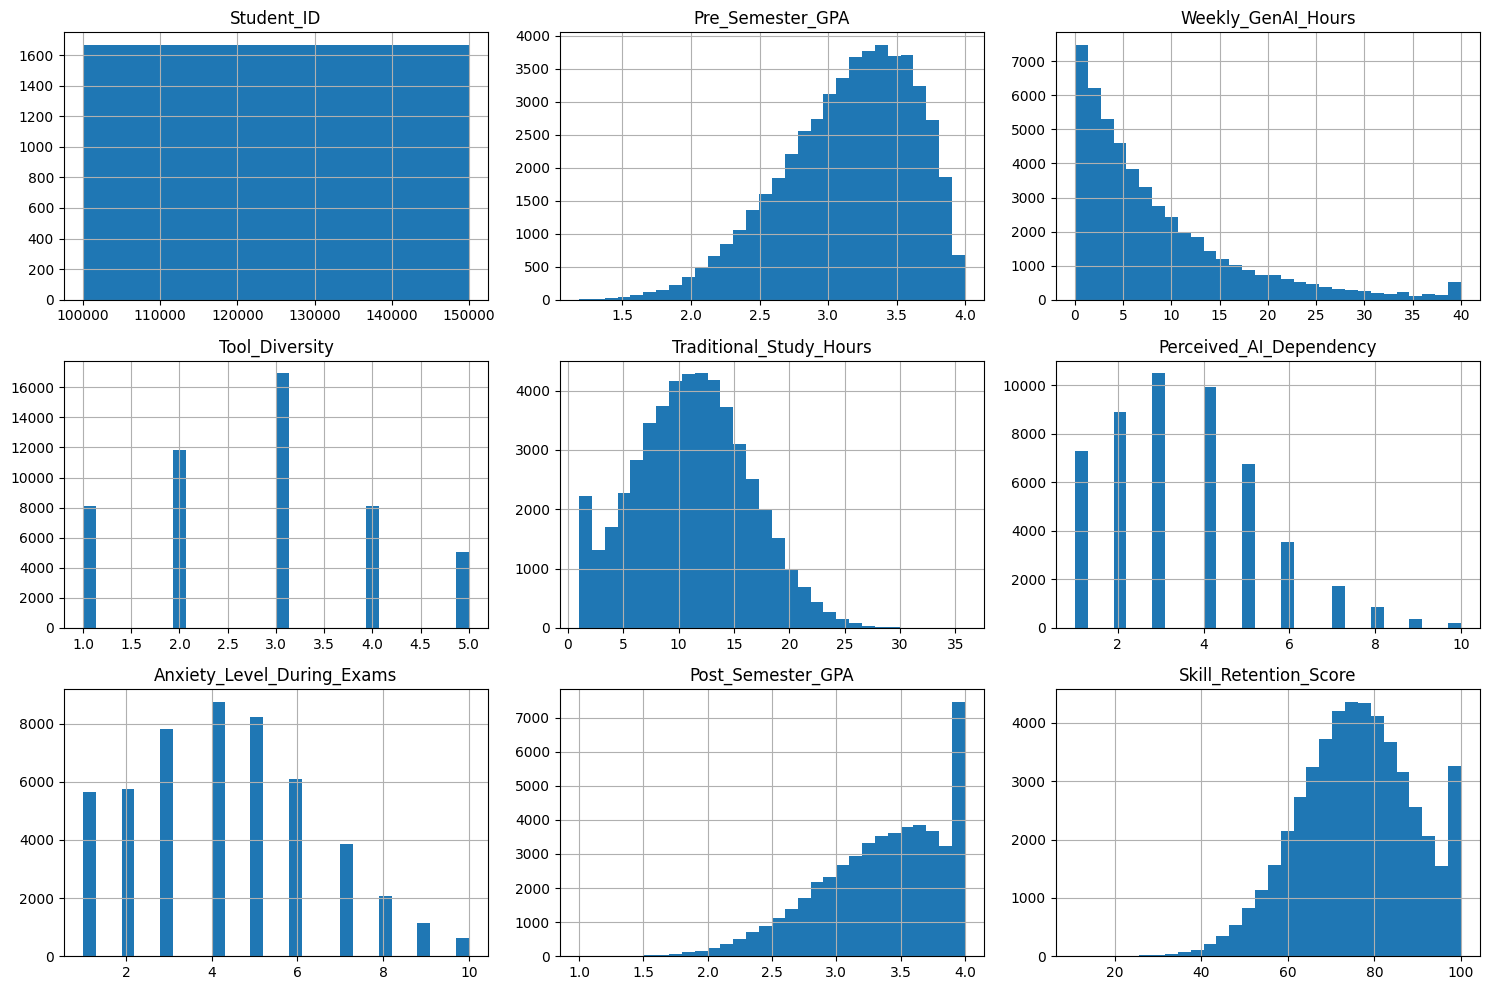

In [55]:
df.hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

##3.5 Tabelas de frequência
As tabelas de frequência mostram a distribuição dos níveis de burnout dentro das diferentes categorias do conjunto de dados. Observa-se que a maioria das categorias apresenta proporções semelhantes entre os níveis Low, Medium e High, indicando que essas variáveis isoladamente não possuem uma separação muito forte entre as classes.

Entretanto, algumas diferenças podem ser observadas. Estudantes classificados como Graduate apresentam a maior proporção de risco High (37%), enquanto Freshman apresentam a menor proporção (18%). A categoria STEM também apresenta uma proporção um pouco maior de risco elevado (30%) em comparação às demais áreas. Além disso, a política institucional Strict_Ban apresenta uma proporção maior de estudantes classificados com High (30%), sugerindo uma possível relação entre restrições ao uso de IA e risco de burnout, que será investigada posteriormente pelos modelos de aprendizado de máquina.

In [56]:
colunas_categoricas = [
    "Major_Category",
    "Year_of_Study",
    "Primary_Use_Case",
    "Prompt_Engineering_Skill",
    "Institutional_Policy"
]

for col in colunas_categoricas:
    print(f"\n--- {col} ---")

    tabela = pd.crosstab(
        df[col],
        df["Burnout_Risk_Level"],
        normalize="index"
    )

    print(tabela.round(2))


--- Major_Category ---
Burnout_Risk_Level  High   Low  Medium
Major_Category                        
Arts                0.23  0.34    0.43
Business            0.24  0.33    0.42
Humanities          0.21  0.36    0.43
Medical             0.23  0.35    0.42
STEM                0.30  0.29    0.41

--- Year_of_Study ---
Burnout_Risk_Level  High   Low  Medium
Year_of_Study                         
Freshman            0.18  0.42    0.40
Graduate            0.37  0.20    0.43
Junior              0.24  0.32    0.43
Senior              0.27  0.29    0.44
Sophomore           0.22  0.36    0.42

--- Primary_Use_Case ---
Burnout_Risk_Level         High   Low  Medium
Primary_Use_Case                             
Copywriting/Drafting       0.23  0.34    0.43
Debugging/Troubleshooting  0.27  0.31    0.42
Direct_Answer_Generation   0.27  0.32    0.42
Ideation                   0.24  0.33    0.43
Summarizing_Reading        0.24  0.34    0.42

--- Prompt_Engineering_Skill ---
Burnout_Risk_Level       

##3.6 Matriz de correlação
A matriz de correlação apresenta a relação linear entre as variáveis numéricas do conjunto de dados. Observa-se que não existem correlações extremamente altas entre os atributos, indicando baixa possibilidade de multicolinearidade.

Esse resultado é positivo para a etapa de modelagem, pois indica que as variáveis preditoras apresentam informações relativamente independentes entre si. Dessa forma, reduz-se o risco de diferentes atributos representarem praticamente o mesmo comportamento, permitindo que os modelos de aprendizado de máquina utilizem um conjunto mais diversificado de características.

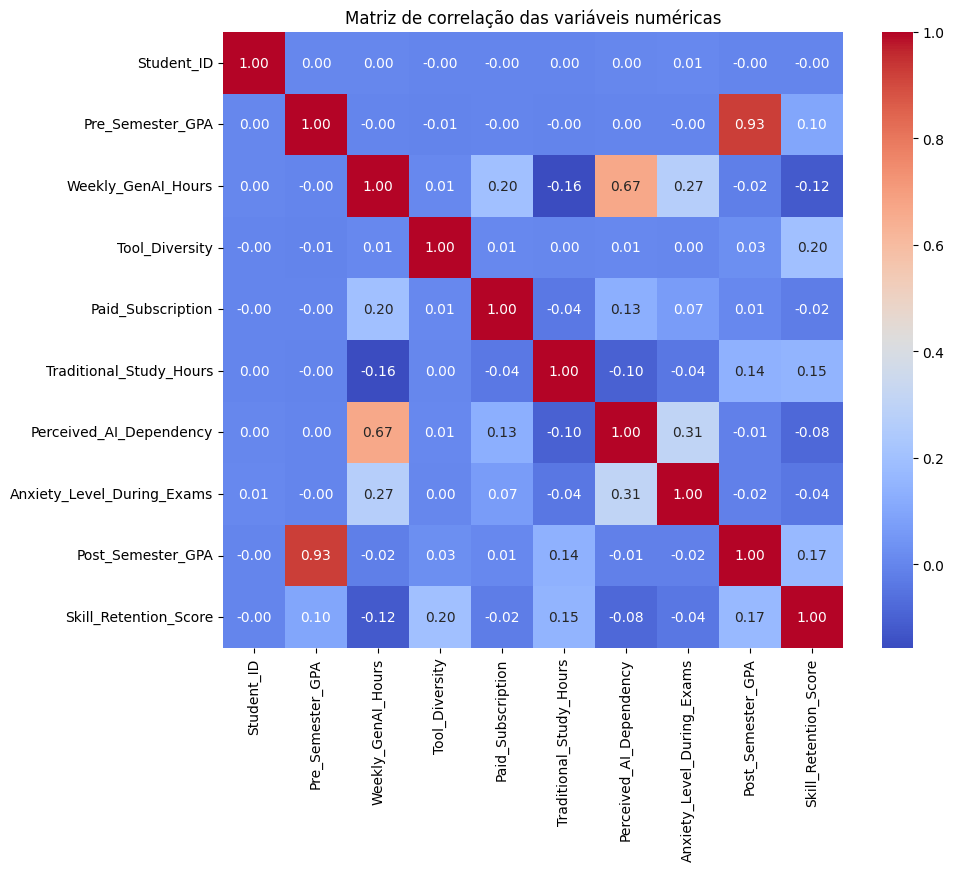

In [57]:
plt.figure(figsize=(10,8))

correlacao = df.corr(numeric_only=True)

sns.heatmap(
    correlacao,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlação das variáveis numéricas")

plt.show()

#4 Pré processamento
##4.1 Valores ausentes
Já verificado na seção 2: o dataset não apresenta valores ausentes em nenhuma das 16 colunas. Por isso, nenhuma técnica de imputação (substituição por mediana, média ou valor mais frequente) é necessária neste caso. Ainda assim, o pipeline de pré-processamento montado adiante inclui um `SimpleImputer` como medida de segurança, garantindo que o notebook não quebre caso o dataset seja atualizado no futuro com registros incompletos.

In [58]:
df.isnull().sum().sum()  #deve retornar 0

np.int64(0)

##4.2 Duplicações
Já verificado na seção 2: `df.duplicated().sum()` retornou 0. Nenhum tratamento de deduplicação é necessário.

In [59]:
df.duplicated().sum()

np.int64(0)

##4.3 Atributos irrelevantes

`Student_ID` é um identificador único por estudante, sem relação causal com o risco de burnout — mantê-lo como preditor apenas introduziria ruído (ou, na pior hipótese, permitiria ao modelo "decorar" o índice em vez de aprender padrões reais). Por isso, essa coluna é descartada antes da modelagem. Em seguida, separamos os preditores (`X`) do atributo-alvo (`y`), garantindo que nenhuma transformação futura (como escalonamento) seja aplicada ao alvo por engano — o alvo é categórico e não deve ser tratado da mesma forma que os preditores numéricos.

In [60]:
df_features = df.drop(columns=["Student_ID"])

X = df_features.drop(columns=["Burnout_Risk_Level"])
y = df_features["Burnout_Risk_Level"]

##4.4 Inconsistências

A verificação das categorias de cada variável categórica confirma um conjunto pequeno e consistente de valores, sem variações de grafia, espaços extras ou erros de digitação (por exemplo, não há "Freshman" e "freshman" registrados como categorias distintas). Isso significa que nenhuma limpeza textual é necessária antes da codificação.

In [61]:
colunas_categoricas = ["Major_Category", "Year_of_Study", "Primary_Use_Case",
                       "Prompt_Engineering_Skill", "Institutional_Policy"]

for col in colunas_categoricas:
    print(f"{col}: {sorted(X[col].unique())}")

Major_Category: ['Arts', 'Business', 'Humanities', 'Medical', 'STEM']
Year_of_Study: ['Freshman', 'Graduate', 'Junior', 'Senior', 'Sophomore']
Primary_Use_Case: ['Copywriting/Drafting', 'Debugging/Troubleshooting', 'Direct_Answer_Generation', 'Ideation', 'Summarizing_Reading']
Prompt_Engineering_Skill: ['Advanced', 'Beginner', 'Intermediate']
Institutional_Policy: ['Actively_Encouraged', 'Allowed_With_Citation', 'Strict_Ban']


##4.5 Valores extremos

Usamos a regra do intervalo interquartil (IQR) para identificar valores extremos em cada variável numérica. A maioria das variáveis apresenta uma proporção muito baixa de outliers pelo critério do IQR: `Traditional_Study_Hours` (0,32%), `Pre_Semester_GPA` (0,66%), `Post_Semester_GPA` (0,69%), `Skill_Retention_Score` (0,43%) e `Perceived_AI_Dependency` (0,38%). Já `Tool_Diversity` e `Anxiety_Level_During_Exams` não apresentam nenhum outlier pelo critério do IQR, o que é esperado, já que são escalas discretas curtas (1 a 5 e 1 a 10, respectivamente), com pouco espaço para valores extremos segundo esse método.

A exceção é `Weekly_GenAI_Hours`, que apresenta 5,17% de outliers (2.583 registros), todos no limite superior — ou seja, estudantes com uso de IA generativa

In [62]:
colunas_numericas = ["Weekly_GenAI_Hours", "Traditional_Study_Hours", "Pre_Semester_GPA",
                      "Post_Semester_GPA", "Skill_Retention_Score", "Tool_Diversity",
                      "Anxiety_Level_During_Exams", "Perceived_AI_Dependency"]

for col in colunas_numericas:
    q1, q3 = X[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inf, limite_sup = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = X[(X[col] < limite_inf) | (X[col] > limite_sup)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(X)*100:.2f}%)")

Weekly_GenAI_Hours: 2583 outliers (5.17%)
Traditional_Study_Hours: 161 outliers (0.32%)
Pre_Semester_GPA: 328 outliers (0.66%)
Post_Semester_GPA: 346 outliers (0.69%)
Skill_Retention_Score: 216 outliers (0.43%)
Tool_Diversity: 0 outliers (0.00%)
Anxiety_Level_During_Exams: 0 outliers (0.00%)
Perceived_AI_Dependency: 190 outliers (0.38%)


##4.6 Variáveis categóricas e escalonamento

O pré-processamento trata cada tipo de variável de forma adequada: variáveis numéricas recebem escalonamento via `StandardScaler` (necessário para o `SGDClassifier`, que é sensível à escala dos atributos, e inofensivo para a `RandomForestClassifier`, que não depende de escala). Variáveis nominais (`Major_Category`, `Primary_Use_Case`, `Institutional_Policy`) recebem codificação one-hot, pois não possuem ordem natural entre categorias. Já `Year_of_Study` e `Prompt_Engineering_Skill` recebem codificação ordinal, preservando a ordem natural das categorias (por exemplo, Freshman < Sophomore < Junior < Senior), o que é mais apropriado do que one-hot para variáveis com hierarquia implícita. `Paid_Subscription`, por já ser booleana, é tratada como numérica sem necessidade de codificação adicional.

In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

colunas_nominais = ["Major_Category", "Primary_Use_Case", "Institutional_Policy"]
ordem_ano = [["Freshman", "Sophomore", "Junior", "Senior", "Graduate"]]
ordem_skill = [["Beginner", "Intermediate", "Advanced"]]

pipeline_numerico = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

pipeline_nominal = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

pipeline_ano = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=ordem_ano)),
])

pipeline_skill = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=ordem_skill)),
])

preprocessamento = ColumnTransformer([
    ("num", pipeline_numerico, colunas_numericas + ["Tool_Diversity", "Paid_Subscription"]),
    ("nom", pipeline_nominal, colunas_nominais),
    ("ano", pipeline_ano, ["Year_of_Study"]),
    ("skill", pipeline_skill, ["Prompt_Engineering_Skill"]),
])

##4.7 Prevenção de vazamento de dados (data leakage)

Um ponto crítico do pré-processamento é evitar vazamento de informação entre os conjuntos de treinamento e teste. Por isso, o pipeline `preprocessamento` **não será ajustado (`fit`) no dataset completo** — ele será ajustado apenas nos dados de treinamento (seção 5), e depois aplicado (`transform`) ao conjunto de teste. Isso garante que estatísticas como a mediana e o desvio-padrão usados no escalonamento sejam calculadas exclusivamente a partir dos dados de treino, simulando corretamente o cenário real onde o modelo não tem acesso a informações do futuro (dados de teste) no momento do treinamento.

Vale reforçar também a discussão já feita sobre `Anxiety_Level_During_Exams` e `Perceived_AI_Dependency`: mantivemos essas variáveis como preditoras (decisão justificada na seção 1), mas o uso do pipeline aqui resolve apenas o vazamento estatístico entre treino/teste — não o vazamento conceitual, cuja justificativa continua sendo uma decisão de modelagem discutida à parte.

##4.8 Classes desbalanceadas

Como identificado na seção 2: `Burnout_Risk_Level` apresenta desbalanceamento leve a moderado (Medium 42,3%, Low 32,7%, High 25,0%). Optamos por **não aplicar** técnicas de balanceamento artificial (como oversampling ou undersampling), já que o desbalanceamento não é extremo. Em vez disso, o tratamento será feito em duas frentes, nas próximas seções: (1) separação estratificada dos dados (seção 5), garantindo que treino e teste mantenham a mesma proporção de classes; e (2) uso de métricas de avaliação apropriadas para dados desbalanceados, como F1-score macro, em vez de acurácia isolada (seção 7).

#5 Separação dos Dados
##5.1 Separação treino e teste

Separamos o conjunto de dados em treino e teste, usando uma proporção de 80% para treino e 20% para teste — uma escolha padrão para datasets de porte médio a grande. Com 50.000 registros, isso deixa 10.000 registros reservados para teste, um volume amplo o suficiente para uma avaliação final estatisticamente confiável, sem sacrificar dados de treinamento.

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##5.2 Estratificação

Como identificado nas seções 2 e 4, o atributo-alvo `Burnout_Risk_Level` apresenta desbalanceamento leve a moderado entre as três classes (Medium 42,3%, Low 32,7%, High 25,0%). Se a separação fosse puramente aleatória, o conjunto de teste poderia, por acaso, ficar com uma proporção de classes bem diferente da distribuição real — por exemplo, com menos casos de `High`, tornando a avaliação menos confiável justamente para a classe mais crítica.

Por isso, refazemos a separação usando o parâmetro `stratify`, garantindo que treino e teste mantenham a mesma proporção das três classes observada no dataset completo.

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

## 5.3 Verificação da estratificação

Conferimos que a proporção das classes se manteve equivalente entre o conjunto completo, o treino e o teste, confirmando que a estratificação funcionou como esperado.

In [66]:
import pandas as pd

comparacao = pd.DataFrame({
    "Completo": y.value_counts(normalize=True),
    "Treino": y_train.value_counts(normalize=True),
    "Teste": y_test.value_counts(normalize=True),
}).round(4)

print(comparacao)

                    Completo  Treino   Teste
Burnout_Risk_Level                          
Medium                0.4229  0.4229  0.4229
Low                   0.3274  0.3274  0.3274
High                  0.2497  0.2498  0.2497


##5.4 Reserva do conjunto de teste

A partir deste ponto, `X_test` e `y_test` ficam reservados exclusivamente para a avaliação final do modelo escolhido (seção 7) e não serão usados em nenhuma etapa de exploração, ajuste de hiperparâmetros ou comparação entre modelos daqui em diante. Isso evita o chamado "data snooping bias": olhar repetidamente para o desempenho no teste durante o desenvolvimento acabaria indiretamente ajustando o modelo a esse conjunto específico, fazendo a estimativa final deixar de refletir a capacidade real de generalização para dados novos.

##5.5 Validação para comparação de modelos

Para comparar os modelos candidatos (seção 6) sem tocar no conjunto de teste, usamos validação cruzada estratificada (`StratifiedKFold`) dentro do próprio conjunto de treino. Essa técnica divide o treino em `k` partes, treina o modelo em `k-1` partes e valida na parte restante, repetindo o processo `k` vezes com uma parte de validação diferente a cada rodada. Isso fornece uma estimativa de desempenho mais robusta do que uma única divisão treino/validação, além de indicar a variabilidade dos resultados entre diferentes subdivisões — informação usada na comparação final entre `SGDClassifier` e `RandomForestClassifier`.

In [67]:
from sklearn.model_selection import StratifiedKFold

cv_estratificado = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#6 Modelagem
##6.1 Baseline

Antes de treinar os modelos propriamente ditos, estabelecemos um baseline — um classificador ingênuo que serve como referência mínima de comparação. Usamos o `DummyClassifier` com estratégia `stratified`, que gera previsões aleatórias respeitando a proporção das classes no treino. Qualquer modelo real precisa superar esse baseline para ser considerado útil; caso contrário, isso indicaria que o modelo não está aprendendo nenhum padrão real dos dados.

In [68]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

baseline = DummyClassifier(strategy="stratified", random_state=42)
baseline_scores = cross_val_score(baseline, X_train, y_train, cv=cv_estratificado, scoring="f1_macro")

print(f"F1-macro do baseline: {baseline_scores.mean():.4f} (+/- {baseline_scores.std():.4f})")

F1-macro do baseline: 0.3319 (+/- 0.0022)


##6.2 SGDClassifier

O `SGDClassifier` é um classificador linear treinado por gradiente descendente estocástico — um dos modelos mínimos exigidos para a tarefa de classificação. Por ser um modelo linear sensível à escala dos atributos, ele depende diretamente do escalonamento aplicado no pré-processamento (seção 4.6). Combinamos o pré-processamento e o classificador em um único pipeline, garantindo que o `fit` do pré-processamento ocorra apenas nos dados de treino em cada fold da validação cruzada — evitando vazamento de dados também durante a comparação de modelos.

In [69]:
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline

pipeline_sgd = Pipeline([
    ("preprocessamento", preprocessamento),
    ("classificador", SGDClassifier(random_state=42)),
])

sgd_scores = cross_val_score(pipeline_sgd, X_train, y_train, cv=cv_estratificado, scoring="f1_macro")

print(f"F1-macro do SGDClassifier: {sgd_scores.mean():.4f} (+/- {sgd_scores.std():.4f})")

F1-macro do SGDClassifier: 0.4696 (+/- 0.0313)


##6.3 RandomForestClassifier

A `RandomForestClassifier` é um modelo de ensemble baseado em múltiplas árvores de decisão treinadas em subconjuntos aleatórios dos dados e dos atributos, com a previsão final definida por votação entre as árvores. É o segundo modelo mínimo exigido, e tende a lidar melhor com relações não lineares entre variáveis do que o `SGDClassifier`, além de ser mais robusta a outliers e não depender de escalonamento.

In [70]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ("preprocessamento", preprocessamento),
    ("classificador", RandomForestClassifier(random_state=42)),
])

rf_scores = cross_val_score(pipeline_rf, X_train, y_train, cv=cv_estratificado, scoring="f1_macro")

print(f"F1-macro da RandomForestClassifier: {rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")

F1-macro da RandomForestClassifier: 0.5239 (+/- 0.0048)


##6.4 Comparação entre os modelos

Comparamos os três resultados (baseline, SGDClassifier e RandomForestClassifier) lado a lado, usando a média e o desvio-padrão do F1-macro obtidos na validação cruzada.

In [71]:
import pandas as pd

resultados = pd.DataFrame({
    "Modelo": ["Baseline", "SGDClassifier", "RandomForestClassifier"],
    "F1-macro médio": [baseline_scores.mean(), sgd_scores.mean(), rf_scores.mean()],
    "Desvio-padrão": [baseline_scores.std(), sgd_scores.std(), rf_scores.std()],
})

print(resultados.round(4))

                   Modelo  F1-macro médio  Desvio-padrão
0                Baseline          0.3319         0.0022
1           SGDClassifier          0.4696         0.0313
2  RandomForestClassifier          0.5239         0.0048


##Interpretação dos resultados

Os resultados da validação cruzada mostram uma progressão clara de desempenho:

| Modelo | F1-macro médio | Desvio-padrão |
|---|---|---|
| Baseline | 0,3319 | 0,0022 |
| SGDClassifier | 0,4696 | 0,0313 |
| RandomForestClassifier | 0,5239 | 0,0048 |

Ambos os modelos superam claramente o baseline (um classificador que apenas segue a proporção das classes sem aprender nenhum padrão real), confirmando que existe sinal preditivo real nos dados para o problema de burnout — o F1-macro do SGDClassifier é cerca de 41% maior que o do baseline, e o da Random Forest é cerca de 58% maior.

A `RandomForestClassifier` apresenta o melhor desempenho entre os três, com F1-macro médio de 0,5239, superando o `SGDClassifier` (0,4696) por uma margem consistente. Isso é esperado e coerente com a natureza do problema: como discutido na análise exploratória (seção 3), não há uma separação linear clara entre as classes de burnout a partir de uma ou duas variáveis isoladas — a Random Forest, por capturar relações não lineares e interações entre atributos (por exemplo, entre uso de IA, ansiedade e política institucional), consegue explorar melhor esse tipo de padrão do que um modelo linear como o SGD.

Vale notar também a diferença no desvio-padrão entre os dois modelos: o SGDClassifier apresenta uma variabilidade bem maior entre os folds (0,0313) do que a Random Forest (0,0048). Isso sugere que o desempenho do SGD é mais instável — mais sensível a qual parte específica dos dados cai em cada fold —, enquanto a Random Forest apresenta resultados mais consistentes e previsíveis entre diferentes subdivisões do treino.

Com base nesses resultados, a **RandomForestClassifier** é **selecionada** como modelo final para a avaliação no conjunto de teste (seção 7), por apresentar tanto o melhor desempenho médio quanto a maior estabilidade entre as validações.

##6.5 Parâmetros principais dos modelos

Os dois modelos foram treinados com seus hiperparâmetros padrão do scikit-learn nesta etapa de comparação inicial, sem ajuste fino (que poderia ser feito posteriormente via `GridSearchCV` ou `RandomizedSearchCV`, mas não é exigido pelo enunciado). Os parâmetros principais de cada modelo são:

**SGDClassifier**: `loss='hinge'` (equivalente a um SVM linear), `penalty='l2'` (regularização L2), `alpha=0.0001` (força da regularização), `max_iter=1000`.

**RandomForestClassifier**: `n_estimators=100` (número de árvores), `criterion='gini'` (critério de divisão dos nós), `max_depth=None` (árvores crescem sem limite de profundidade até as folhas serem puras), `min_samples_split=2`.

In [72]:
print("SGDClassifier:", pipeline_sgd.named_steps["classificador"].get_params())
print()
print("RandomForestClassifier:", pipeline_rf.named_steps["classificador"].get_params())

SGDClassifier: {'alpha': 0.0001, 'average': False, 'class_weight': None, 'early_stopping': False, 'epsilon': 0.1, 'eta0': 0.0, 'fit_intercept': True, 'l1_ratio': 0.15, 'learning_rate': 'optimal', 'loss': 'hinge', 'max_iter': 1000, 'n_iter_no_change': 5, 'n_jobs': None, 'penalty': 'l2', 'power_t': 0.5, 'random_state': 42, 'shuffle': True, 'tol': 0.001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}

RandomForestClassifier: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


##7.1 Treinamento do modelo final

Com a `RandomForestClassifier` selecionada como modelo final na seção 6, treinamos essa versão do pipeline completo (pré-processamento + classificador) usando **todo o conjunto de treinamento** (não apenas os folds da validação cruzada), para aproveitar o máximo de dados disponível antes da avaliação final no conjunto de teste, que permanece intocado até este momento.

In [73]:
pipeline_rf.fit(X_train, y_train)

y_pred = pipeline_rf.predict(X_test)

##7.2 Matriz de confusão

A matriz de confusão mostra, para cada classe real, quantas previsões o modelo acertou e para quais outras classes ele errou. Isso é especialmente importante aqui, porque a acurácia sozinha (próxima subseção) esconde onde exatamente o modelo está confundindo as classes — por exemplo, se o erro se concentra entre classes vizinhas (Low com Medium) ou entre extremos (Low com High, o que seria um erro mais grave).

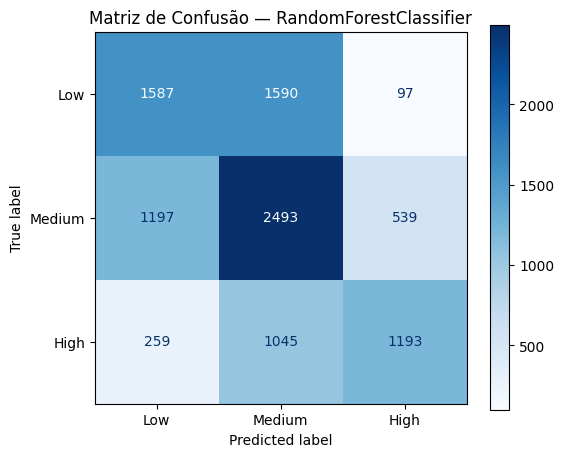

In [74]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, labels=["Low", "Medium", "High"],
    cmap="Blues", ax=ax, colorbar=True
)
plt.title("Matriz de Confusão — RandomForestClassifier")
plt.show()

**Interpretação:**

A matriz de confusão revela um padrão consistente com a natureza ordinal do problema — a maior parte da confusão do modelo ocorre entre classes **adjacentes**, não entre os extremos:

- **Low**: das 3.274 instâncias reais, o modelo acertou 1.587 (48,5%), confundiu 1.590 com Medium (48,6%) e apenas 97 com High (3,0%).
- **Medium**: das 4.229 instâncias reais, acertou 2.493 (59,0%) — a classe com melhor revocação —, confundindo 1.197 com Low (28,3%) e 539 com High (12,7%).
- **High**: das 2.497 instâncias reais, acertou 1.193 (47,8%), confundiu 1.045 com Medium (41,9%) e 259 com Low (10,4%).

O ponto mais importante para a discussão: a confusão direta entre os dois extremos (Low ↔ High) é a **menor de todas** em proporção (3,0% e 10,4%), enquanto a confusão entre classes vizinhas (Low-Medium e Medium-High) é consideravelmente maior — especialmente entre Low e Medium, que juntas somam praticamente metade das instâncias de Low. Isso é um sinal positivo: o modelo raramente comete o erro mais grave na prática, que seria confundir risco baixo com risco alto (ou vice-versa).

Ainda assim, vale destacar como limitação: os 259 casos (10,4%) de estudantes com risco **High** classificados como **Low** — somados aos 1.045 casos (41,9%) classificados como **Medium** — mostram que o modelo deixa passar mais da metade dos estudantes em risco real (52,2% de erro nessa classe). Esse achado é aprofundado na seção 7.4, onde a revocação da classe High (0,4778) confirma numericamente esse padrão observado aqui visualmente.

##7.3 Acurácia

A acurácia mede a proporção total de previsões corretas, sem distinguir entre classes. Como já discutido nas seções 2 e 5, essa métrica isolada pode ser enganosa aqui devido ao desbalanceamento: um classificador que sempre previsse "Medium" já acertaria cerca de 42% dos casos sem aprender nenhum padrão real. Por isso, apresentamos a acurácia apenas como referência complementar, não como métrica principal de decisão.

In [75]:
from sklearn.metrics import accuracy_score

acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acuracia:.4f}")

Acurácia: 0.5273


##7.4 Precisão, revocação e F1-score

Usamos o `classification_report`, que calcula precisão, revocação e F1-score **por classe**, além das médias macro (que tratam as três classes com peso igual) e weighted (que pondera pelo tamanho de cada classe). A métrica macro é a mais relevante para este projeto, dado o desbalanceamento identificado — ela evita que o desempenho na classe majoritária (Medium) mascare um desempenho ruim na classe minoritária (High), que é justamente a mais crítica de identificar corretamente na prática.

**Interpretação:**

Com os rótulos corrigidos, o relatório revela um padrão interessante e mais informativo do que a acurácia isolada sugeria:

- **Low**: precisão 0,5215, revocação 0,4847, F1 0,5025 — desempenho equilibrado, mas modesto.
- **Medium**: precisão 0,4862 (a mais baixa das três), revocação 0,5895 (a mais alta), F1 0,5329 — o modelo "chuta" Medium com mais frequência, acertando a maioria das vezes que a classe real é Medium, mas à custa de confundir outras classes como Medium também (por isso a precisão mais baixa).
- **High**: precisão 0,6523 (a mais alta das três), revocação 0,4778 (a mais baixa) — quando o modelo prevê High, ele costuma acertar (65% das vezes), mas ele **deixa passar mais da metade** dos casos reais de risco alto, classificando-os como Medium ou Low.

Esse último ponto é o achado mais relevante para a discussão crítica do projeto: a classe mais importante de se identificar corretamente na prática — High — é justamente a que tem a menor revocação. Ou seja, o modelo é "conservador" ao prever risco alto (só marca quando tem bastante certeza), mas isso tem um custo real: muitos estudantes em risco alto não seriam sinalizados por esse classificador.

O F1-macro obtido no teste (0,5290) é consistente com o F1-macro médio obtido na validação cruzada (0,5239 — seção 6.4), o que indica que o modelo generalizou bem, sem sinais de overfitting ao conjunto de treino.

In [76]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, labels=["Low", "Medium", "High"], target_names=["Low", "Medium", "High"], digits=4))

              precision    recall  f1-score   support

         Low     0.5215    0.4847    0.5025      3274
      Medium     0.4862    0.5895    0.5329      4229
        High     0.6523    0.4778    0.5515      2497

    accuracy                         0.5273     10000
   macro avg     0.5533    0.5173    0.5290     10000
weighted avg     0.5392    0.5273    0.5276     10000



##7.5 Discussão

**Qual modelo apresentou o melhor resultado e por quê:** a `RandomForestClassifier` foi selecionada na seção 6 por apresentar o maior F1-macro médio (0,5239) e a maior estabilidade entre os folds de validação cruzada, em comparação ao `SGDClassifier` (0,4696) e ao baseline (0,3319). Isso é coerente com a natureza não linear do problema, identificada na análise exploratória (seção 3): as variáveis preditoras não separam as classes de burnout de forma linear, favorecendo um modelo de ensemble baseado em árvores.

**Quais erros foram observados:**

O erro mais significativo do modelo é a baixa revocação na classe High (0,4778) — mais da metade dos estudantes com risco real de burnout alto é classificada incorretamente como Medium ou Low.

Em contrapartida, a precisão da classe High é a mais alta das três (0,6523), indicando que o modelo é *conservador*: quando afirma que um estudante está em risco alto, costuma acertar, mas deixa passar muitos casos reais.

Já a classe Medium apresenta o padrão oposto — maior revocação (0,5895), porém menor precisão (0,4862) —, sugerindo que o modelo tende a "default" para Medium com mais frequência do que deveria em casos ambíguos.

**Quais limitações existem:**
- O F1-macro de aproximadamente 0,52 indica desempenho moderado, não excelente — há espaço considerável para melhoria, especialmente na distinção entre classes adjacentes.
- O fato de o dataset ser sintético (seção 2), limitou a capacidade de generalização das conclusões para estudantes reais; os padrões aprendidos podem refletir regras do gerador de dados, não necessariamente comportamento humano genuíno.
- As variáveis `Anxiety_Level_During_Exams` e `Perceived_AI_Dependency`, mantidas como preditoras (seção 1), têm proximidade conceitual com o próprio alvo, o que pode inflar artificialmente o desempenho do modelo em relação ao que seria observado com preditores mais estritamente comportamentais.
- A análise exploratória (seções 2 e 3) foi feita no dataset completo, não apenas no treino — uma escolha declarada e justificada, mas que tecnicamente introduz um risco pequeno de viés de vazamento na etapa de exploração, ainda que não no treinamento do modelo em si.

**O que poderia ser melhorado:**
- Testar a comparação do modelo com e sem `Anxiety_Level_During_Exams` e `Perceived_AI_Dependency`, para quantificar o quanto essas variáveis "conceitualmente próximas do alvo" influenciam o resultado.
- Aplicar ajuste fino de hiperparâmetros (`GridSearchCV`/`RandomizedSearchCV`) na `RandomForestClassifier`, já que os parâmetros usados até aqui são os padrão do scikit-learn.
- Investigar a importância das variáveis (`feature_importances_`) para entender quais atributos mais pesam nas previsões do modelo.